# 多类型站点拓扑分析

## 目标
1. 各类型站点 (ML/HV/FR/OR/FF) 的数量和分布
2. 位置重叠检测：哪些站点在同一位置（同 Fwy + Dir + 相同/相近 Abs_PM）
3. 匝道 (FR/OR) 与 ML 主链的关联：每个匝道最近的 ML 站点
4. HOV (HV) 与 ML 的平行关系确认
5. FF 站点的特征分析

## 1. 环境配置 & 数据加载

In [1]:
import pandas as pd
import numpy as np
import os
import re
import glob
from datetime import datetime
from collections import defaultdict
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ============== 配置 ==============
META_DIR = "../d03_meta"
OUTPUT_DIR = "../output/topology_analysis"
os.makedirs(OUTPUT_DIR, exist_ok=True)

TARGET_DATE = "2025_01_15"  # 分析的目标日期

# 位置重叠判定阈值（英里）
COLOCATION_THRESHOLD = 0.05  # 0.05 英里 ≈ 80 米

print("库加载完成！")

库加载完成！


In [2]:
# 查找元数据文件
def find_nearest_meta_file(meta_folder, target_date_str):
    target_date = datetime.strptime(target_date_str, '%Y_%m_%d')
    meta_files = glob.glob(os.path.join(meta_folder, "d*_text_meta_*.txt"))
    file_dates = []
    for f in meta_files:
        match = re.search(r'(\d{4})_(\d{2})_(\d{2})', os.path.basename(f))
        if match:
            file_date = datetime(int(match.group(1)), int(match.group(2)), int(match.group(3)))
            file_dates.append((file_date, f))
    if not file_dates:
        return None, None
    valid = [(d, f) for d, f in file_dates if d <= target_date]
    if valid:
        return max(valid, key=lambda x: x[0])
    return min(file_dates, key=lambda x: x[0])


META_COLUMNS = [
    'ID', 'Fwy', 'Dir', 'District', 'County', 'City',
    'State_PM', 'Abs_PM', 'Latitude', 'Longitude', 'Length',
    'Type', 'Lanes', 'Name', 'User_ID_1', 'User_ID_2',
    'User_ID_3', 'User_ID_4'
]

meta_date, meta_file = find_nearest_meta_file(META_DIR, TARGET_DATE)
print(f"元数据文件: {meta_file}")
print(f"元数据日期: {meta_date.strftime('%Y-%m-%d')}")

meta_df = pd.read_csv(
    meta_file, sep='\t', names=META_COLUMNS, header=0,
    dtype={'ID': str, 'Fwy': str}
)
print(f"\n总站点数: {len(meta_df)}")

元数据文件: ../d03_meta/d03_text_meta_2024_11_27.txt
元数据日期: 2024-11-27

总站点数: 1859


## 2. 各类型站点概览

In [3]:
print("="*60)
print("各类型站点数量")
print("="*60)

type_counts = meta_df['Type'].value_counts()
print(type_counts)
print(f"\n总计: {len(meta_df)}")

# 各类型的车道数分布
print(f"\n各类型的车道数分布:")
for t in meta_df['Type'].unique():
    subset = meta_df[meta_df['Type'] == t]
    print(f"\n  {t} (n={len(subset)}):")
    print(f"    车道数: {subset['Lanes'].describe()[['mean','min','max']].to_dict()}")
    print(f"    车道数分布: {subset['Lanes'].value_counts().sort_index().to_dict()}")

各类型站点数量
Type
ML    871
OR    417
HV    272
FR    271
FF     28
Name: count, dtype: int64

总计: 1859

各类型的车道数分布:

  ML (n=871):
    车道数: {'mean': 2.6991963260619976, 'min': 1.0, 'max': 6.0}
    车道数分布: {1: 98, 2: 328, 3: 242, 4: 148, 5: 51, 6: 4}

  OR (n=417):
    车道数: {'mean': 1.3669064748201438, 'min': 1.0, 'max': 3.0}
    车道数分布: {1: 276, 2: 129, 3: 12}

  FR (n=271):
    车道数: {'mean': 1.4317343173431734, 'min': 1.0, 'max': 4.0}
    车道数分布: {1: 170, 2: 88, 3: 10, 4: 3}

  FF (n=28):
    车道数: {'mean': 1.8214285714285714, 'min': 1.0, 'max': 3.0}
    车道数分布: {1: 8, 2: 17, 3: 3}

  HV (n=272):
    车道数: {'mean': 1.0, 'min': 1.0, 'max': 1.0}
    车道数分布: {1: 272}


In [4]:
# 各类型在各高速公路上的分布
print("="*60)
print("各类型在各 (Fwy, Dir) 上的分布")
print("="*60)

type_by_fwy = meta_df.groupby(['Fwy', 'Dir', 'Type']).size().unstack(fill_value=0)
print(f"\n(Fwy, Dir) 组合数: {len(type_by_fwy)}")
display(type_by_fwy)

各类型在各 (Fwy, Dir) 上的分布

(Fwy, Dir) 组合数: 42


Type     FF  FR  HV   ML  OR
Fwy Dir                     
113 N     0   2   0    5   2
    S     0   2   0    5   3
12  E     0   0   0    7   0
    W     0   0   0    5   0
16  W     0   0   0    1   0
160 N     1   1   0    2   1
    S     0   1   0    3   1
162 E     0   0   0    4   0
    W     0   0   0    2   0
193 E     0   0   0    0   1
    W     0   0   0    0   1
20  E     0   5   0    9   7
    W     0   4   0   11   4
244 E     0   0   0    1   0
    W     0   0   0    3   0
267 E     0   0   0    2   0
    W     0   0   0    2   0
275 W     0   0   0    1   1
28  E     0   0   0    3   0
    W     0   0   0    3   0
45  N     0   0   0    3   0
    S     0   0   0    3   0
49  N     0   2   0    3   1
    S     0   1   0    3   2
5   N     2  20  17   56  44
    S     6  19  14   53  41
50  E     6  24  52  109  48
    W     2  26  49  105  42
505 N     0   0   0    1   0
    S     0   0   0    1   0
51  N     2  16   1   22   9
    S     1   7   3   19  12
65  N     0   5   0   15   9
    S     2   5   0   17  12
70  E     0   2   0    8   3
    W     0   2   0    7   2
80  E     2  41  40  100  51
    W     1  40  44   98  51
89  N     0   0   0   10   0
    S     0   0   0   10   0
99  N     2  19  28   75  36
    S     1  27  24   84  33

In [5]:
# 哪些 (Fwy, Dir) 有匝道站点
print("\n有匝道(FR/OR)的高速:")
has_ramp = type_by_fwy[type_by_fwy.get('FR', pd.Series(0)).add(type_by_fwy.get('OR', pd.Series(0)), fill_value=0) > 0]
if 'FR' in type_by_fwy.columns or 'OR' in type_by_fwy.columns:
    ramp_cols = [c for c in ['FR', 'OR'] if c in type_by_fwy.columns]
    has_ramp = type_by_fwy[type_by_fwy[ramp_cols].sum(axis=1) > 0]
    print(f"  {len(has_ramp)} 个 (Fwy, Dir) 有匝道站点")

# 哪些 (Fwy, Dir) 有 HV
if 'HV' in type_by_fwy.columns:
    has_hv = type_by_fwy[type_by_fwy['HV'] > 0]
    print(f"  {len(has_hv)} 个 (Fwy, Dir) 有 HV 站点")

# 哪些 (Fwy, Dir) 有 FF
if 'FF' in type_by_fwy.columns:
    has_ff = type_by_fwy[type_by_fwy['FF'] > 0]
    print(f"  {len(has_ff)} 个 (Fwy, Dir) 有 FF 站点")


有匝道(FR/OR)的高速:
  25 个 (Fwy, Dir) 有匝道站点
  10 个 (Fwy, Dir) 有 HV 站点
  12 个 (Fwy, Dir) 有 FF 站点


## 3. 位置重叠检测

找出在同一 (Fwy, Dir) 上 Abs_PM 差值 < 阈值的站点组

In [6]:
def detect_colocated_groups(meta_df, threshold=0.05):
    """
    检测同位置站点组。
    
    同一 (Fwy, Dir) 上 Abs_PM 差值 < threshold 的站点归为一组。
    """
    groups = []
    group_id = 0
    
    for (fwy, direction), fwy_group in meta_df.groupby(['Fwy', 'Dir']):
        sorted_df = fwy_group.sort_values('Abs_PM').reset_index(drop=True)
        n = len(sorted_df)
        
        if n < 2:
            continue
        
        # 用贪心法分组：连续的近距离站点归为一组
        visited = [False] * n
        
        for i in range(n):
            if visited[i]:
                continue
            
            # 找到所有与 i 距离 < threshold 的站点
            cluster = [i]
            visited[i] = True
            
            for j in range(i + 1, n):
                if visited[j]:
                    continue
                # 与 cluster 中任意一个站点距离 < threshold
                dist = abs(sorted_df.iloc[j]['Abs_PM'] - sorted_df.iloc[i]['Abs_PM'])
                if dist < threshold:
                    cluster.append(j)
                    visited[j] = True
                else:
                    break  # 已排序，后面的更远
            
            if len(cluster) >= 2:
                members = sorted_df.iloc[cluster]
                types = sorted(members['Type'].unique())
                
                groups.append({
                    'Group_ID': group_id,
                    'Fwy': fwy,
                    'Dir': direction,
                    'N_Stations': len(cluster),
                    'Types': '+'.join(types),
                    'Type_List': types,
                    'Station_IDs': members['ID'].tolist(),
                    'Station_Types': members['Type'].tolist(),
                    'Station_Lanes': members['Lanes'].tolist(),
                    'Abs_PM_Min': members['Abs_PM'].min(),
                    'Abs_PM_Max': members['Abs_PM'].max(),
                    'Abs_PM_Spread': members['Abs_PM'].max() - members['Abs_PM'].min(),
                    'Lat': members['Latitude'].mean(),
                    'Lon': members['Longitude'].mean(),
                })
                group_id += 1
    
    return pd.DataFrame(groups)


colocated_df = detect_colocated_groups(meta_df, COLOCATION_THRESHOLD)
print(f"检测到 {len(colocated_df)} 个同位置站点组 (阈值: {COLOCATION_THRESHOLD} 英里)")

检测到 493 个同位置站点组 (阈值: 0.05 英里)


In [7]:
# 按类型组合统计
print("="*60)
print("同位置站点组 - 按类型组合统计")
print("="*60)

type_combo_counts = colocated_df['Types'].value_counts()
print(f"\n类型组合分布:")
for combo, count in type_combo_counts.items():
    print(f"  {combo:30s}: {count:>4} 组")

print(f"\n按站点数分布:")
print(colocated_df['N_Stations'].value_counts().sort_index())

同位置站点组 - 按类型组合统计

类型组合分布:
  ML+OR                         :  129 组
  HV+ML+OR                      :   83 组
  HV+ML                         :   80 组
  FR+ML+OR                      :   63 组
  ML                            :   32 组
  FR+ML                         :   31 组
  FR+HV+ML+OR                   :   27 组
  FF+ML                         :   11 组
  FR+HV+ML                      :   10 组
  FR+OR                         :    6 组
  HV+OR                         :    5 组
  FF+FR+ML                      :    3 组
  FR+HV                         :    3 组
  FF                            :    3 组
  FF+ML+OR                      :    2 组
  FR                            :    1 组
  FR+HV+OR                      :    1 组
  FF+OR                         :    1 组
  OR                            :    1 组
  FF+HV                         :    1 组

按站点数分布:
N_Stations
2     246
3     155
4      65
5      21
6       3
8       1
9       1
12      1
Name: count, dtype: int64


In [8]:
# 详细查看各类型组合的例子
print("="*60)
print("各类型组合的典型例子")
print("="*60)

for combo in type_combo_counts.index:
    subset = colocated_df[colocated_df['Types'] == combo]
    example = subset.iloc[0]
    
    print(f"\n--- {combo} (共 {len(subset)} 组) ---")
    print(f"  例: Fwy {example['Fwy']}-{example['Dir']}, PM={example['Abs_PM_Min']:.3f}")
    
    for sid, stype, slanes in zip(example['Station_IDs'], 
                                   example['Station_Types'], 
                                   example['Station_Lanes']):
        print(f"    {sid:>10s}  Type={stype}  Lanes={slanes}")

各类型组合的典型例子

--- ML+OR (共 129 组) ---
  例: Fwy 113-S, PM=22.853
       3034103  Type=OR  Lanes=1
       3034101  Type=ML  Lanes=3

--- HV+ML+OR (共 83 组) ---
  例: Fwy 5-N, PM=507.464
       3013103  Type=HV  Lanes=1
        312133  Type=ML  Lanes=3
        311847  Type=OR  Lanes=3

--- HV+ML (共 80 组) ---
  例: Fwy 5-N, PM=508.020
        317814  Type=ML  Lanes=3
       3043011  Type=HV  Lanes=1
        317815  Type=ML  Lanes=3

--- FR+ML+OR (共 63 组) ---
  例: Fwy 113-N, PM=32.297
        316484  Type=FR  Lanes=2
        316483  Type=OR  Lanes=1
        316482  Type=ML  Lanes=2

--- ML (共 32 组) ---
  例: Fwy 113-S, PM=60.129
       3415047  Type=ML  Lanes=3
       3415044  Type=ML  Lanes=2

--- FR+ML (共 31 组) ---
  例: Fwy 113-N, PM=23.251
       3034107  Type=FR  Lanes=2
       3034105  Type=ML  Lanes=2

--- FR+HV+ML+OR (共 27 组) ---
  例: Fwy 5-N, PM=512.387
        314898  Type=FR  Lanes=1
        314896  Type=OR  Lanes=1
        314899  Type=ML  Lanes=3
       3028031  Type=HV  Lanes=1

--- 

In [9]:
# 重点：涉及 3 种及以上类型的组
complex_groups = colocated_df[colocated_df['Type_List'].apply(len) >= 3]
print(f"\n涉及 3 种及以上类型的同位置组: {len(complex_groups)}")

if len(complex_groups) > 0:
    print("\n详细信息:")
    for _, row in complex_groups.iterrows():
        print(f"\n  组 {row['Group_ID']}: Fwy {row['Fwy']}-{row['Dir']}, "
              f"PM≈{row['Abs_PM_Min']:.3f}, 类型={row['Types']}")
        for sid, stype, slanes in zip(row['Station_IDs'], 
                                       row['Station_Types'], 
                                       row['Station_Lanes']):
            print(f"    {sid:>10s}  Type={stype}  Lanes={slanes}")


涉及 3 种及以上类型的同位置组: 189

详细信息:

  组 1: Fwy 113-N, PM≈32.297, 类型=FR+ML+OR
        316484  Type=FR  Lanes=2
        316483  Type=OR  Lanes=1
        316482  Type=ML  Lanes=2

  组 8: Fwy 160-N, PM≈48.588, 类型=FR+ML+OR
        314521  Type=ML  Lanes=2
        314576  Type=FR  Lanes=1
        314575  Type=OR  Lanes=2

  组 13: Fwy 20-E, PM≈183.792, 类型=FR+ML+OR
       3422045  Type=FR  Lanes=1
       3422044  Type=FR  Lanes=2
       3422043  Type=OR  Lanes=1
       3422042  Type=OR  Lanes=1
       3422041  Type=ML  Lanes=2

  组 14: Fwy 20-W, PM≈182.667, 类型=FR+ML+OR
       3422034  Type=OR  Lanes=1
       3422038  Type=FR  Lanes=2
       3422032  Type=ML  Lanes=2

  组 19: Fwy 5-N, PM≈506.373, 类型=FR+ML+OR
        319256  Type=FR  Lanes=1
        311844  Type=OR  Lanes=2
        312134  Type=ML  Lanes=2
       3013095  Type=OR  Lanes=1

  组 20: Fwy 5-N, PM≈507.464, 类型=HV+ML+OR
       3013103  Type=HV  Lanes=1
        312133  Type=ML  Lanes=3
        311847  Type=OR  Lanes=3

  组 26: Fwy 5-N, PM≈51

## 4. 匝道 (FR/OR) 与 ML 主链的关系

In [10]:
def find_nearest_ml_for_ramps(meta_df):
    """
    对每个匝道站点 (FR/OR)，找到同一 (Fwy, Dir) 上最近的 ML 站点
    """
    ml_df = meta_df[meta_df['Type'] == 'ML'].copy()
    ramp_df = meta_df[meta_df['Type'].isin(['FR', 'OR'])].copy()
    
    results = []
    
    for _, ramp in ramp_df.iterrows():
        # 同一 (Fwy, Dir) 上的 ML
        ml_same = ml_df[(ml_df['Fwy'] == ramp['Fwy']) & (ml_df['Dir'] == ramp['Dir'])]
        
        if len(ml_same) == 0:
            results.append({
                'Ramp_ID': ramp['ID'],
                'Ramp_Type': ramp['Type'],
                'Fwy': ramp['Fwy'],
                'Dir': ramp['Dir'],
                'Ramp_PM': ramp['Abs_PM'],
                'Ramp_Lanes': ramp['Lanes'],
                'Nearest_ML_ID': None,
                'ML_PM': None,
                'Distance_to_ML': None,
                'ML_Lanes': None,
                'Is_Colocated': False,
                # 上游和下游ML
                'Upstream_ML_ID': None,
                'Upstream_ML_Dist': None,
                'Downstream_ML_ID': None,
                'Downstream_ML_Dist': None,
            })
            continue
        
        # 最近的 ML
        distances = (ml_same['Abs_PM'] - ramp['Abs_PM']).abs()
        nearest_idx = distances.idxmin()
        nearest_ml = ml_same.loc[nearest_idx]
        dist_to_ml = abs(nearest_ml['Abs_PM'] - ramp['Abs_PM'])
        
        # 上游 ML（PM < 匝道PM）和下游 ML（PM > 匝道PM）
        upstream = ml_same[ml_same['Abs_PM'] < ramp['Abs_PM']].sort_values('Abs_PM', ascending=False)
        downstream = ml_same[ml_same['Abs_PM'] > ramp['Abs_PM']].sort_values('Abs_PM')
        
        results.append({
            'Ramp_ID': ramp['ID'],
            'Ramp_Type': ramp['Type'],
            'Fwy': ramp['Fwy'],
            'Dir': ramp['Dir'],
            'Ramp_PM': ramp['Abs_PM'],
            'Ramp_Lanes': ramp['Lanes'],
            'Nearest_ML_ID': nearest_ml['ID'],
            'ML_PM': nearest_ml['Abs_PM'],
            'Distance_to_ML': dist_to_ml,
            'ML_Lanes': nearest_ml['Lanes'],
            'Is_Colocated': dist_to_ml < COLOCATION_THRESHOLD,
            # 上游和下游
            'Upstream_ML_ID': upstream.iloc[0]['ID'] if len(upstream) > 0 else None,
            'Upstream_ML_Dist': abs(upstream.iloc[0]['Abs_PM'] - ramp['Abs_PM']) if len(upstream) > 0 else None,
            'Downstream_ML_ID': downstream.iloc[0]['ID'] if len(downstream) > 0 else None,
            'Downstream_ML_Dist': abs(downstream.iloc[0]['Abs_PM'] - ramp['Abs_PM']) if len(downstream) > 0 else None,
        })
    
    return pd.DataFrame(results)


ramp_ml_df = find_nearest_ml_for_ramps(meta_df)
print(f"匝道站点总数: {len(ramp_ml_df)}")
print(f"  FR (出口): {(ramp_ml_df['Ramp_Type'] == 'FR').sum()}")
print(f"  OR (入口): {(ramp_ml_df['Ramp_Type'] == 'OR').sum()}")

匝道站点总数: 688
  FR (出口): 271
  OR (入口): 417


In [11]:
# 匝道与最近 ML 的距离分布
print("="*60)
print("匝道与最近 ML 站点的距离分布")
print("="*60)

valid_ramps = ramp_ml_df[ramp_ml_df['Distance_to_ML'].notna()]
print(f"\n有对应 ML 的匝道: {len(valid_ramps)} / {len(ramp_ml_df)}")
print(f"无对应 ML 的匝道: {ramp_ml_df['Distance_to_ML'].isna().sum()}")

if len(valid_ramps) > 0:
    print(f"\n距离统计 (英里):")
    print(valid_ramps['Distance_to_ML'].describe())
    
    print(f"\n距离分布:")
    bins = [0, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0, 5.0, 999]
    labels = ['<0.05', '0.05-0.1', '0.1-0.2', '0.2-0.5', '0.5-1', '1-2', '2-5', '>5']
    valid_ramps_copy = valid_ramps.copy()
    valid_ramps_copy['Dist_Bin'] = pd.cut(valid_ramps_copy['Distance_to_ML'], bins=bins, labels=labels)
    print(valid_ramps_copy['Dist_Bin'].value_counts().sort_index())
    
    print(f"\n与 ML 同位置 (<{COLOCATION_THRESHOLD}mi) 的匝道: {valid_ramps['Is_Colocated'].sum()}")
    print(f"  FR 同位置: {((valid_ramps['Ramp_Type'] == 'FR') & valid_ramps['Is_Colocated']).sum()}")
    print(f"  OR 同位置: {((valid_ramps['Ramp_Type'] == 'OR') & valid_ramps['Is_Colocated']).sum()}")

匝道与最近 ML 站点的距离分布

有对应 ML 的匝道: 686 / 688
无对应 ML 的匝道: 2

距离统计 (英里):
count    686.000000
mean       0.037348
std        0.071623
min        0.000000
25%        0.000000
50%        0.007000
75%        0.045000
max        0.986000
Name: Distance_to_ML, dtype: float64

距离分布:
Dist_Bin
<0.05       291
0.05-0.1     77
0.1-0.2      60
0.2-0.5      20
0.5-1         2
1-2           0
2-5           0
>5            0
Name: count, dtype: int64

与 ML 同位置 (<0.05mi) 的匝道: 527
  FR 同位置: 158
  OR 同位置: 369


In [12]:
# 查看同位置的匝道+ML 例子
colocated_ramps = valid_ramps[valid_ramps['Is_Colocated']]
print(f"\n同位置匝道+ML 示例:")
display(colocated_ramps[[
    'Ramp_ID', 'Ramp_Type', 'Fwy', 'Dir', 'Ramp_PM', 'Ramp_Lanes',
    'Nearest_ML_ID', 'ML_PM', 'Distance_to_ML', 'ML_Lanes'
]].head(20))


同位置匝道+ML 示例:


,Ramp_ID,Ramp_Type,Fwy,Dir,Ramp_PM,Ramp_Lanes,Nearest_ML_ID,ML_PM,Distance_to_ML,ML_Lanes
0,311831,OR,5,S,506.189,1,312132,506.189,0.000,2.0
1,311832,FR,5,S,506.189,1,312132,506.189,0.000,2.0
2,311844,OR,5,N,506.373,2,312134,506.373,0.000,2.0
3,311847,OR,5,N,507.478,3,312133,507.476,0.002,3.0
5,311973,OR,50,E,4.376,1,311974,4.376,0.000,5.0
6,312009,FR,50,E,4.376,2,311974,4.376,0.000,5.0
7,312011,OR,50,W,4.501,2,312010,4.501,0.000,5.0
8,312012,FR,50,W,4.501,1,312010,4.501,0.000,5.0
9,312099,OR,50,E,5.496,1,312098,5.496,0.000,4.0
10,312104,OR,50,W,6.221,1,312103,6.221,0.000,4.0


In [13]:
# 查看远离 ML 的匝道
far_ramps = valid_ramps[valid_ramps['Distance_to_ML'] > 2.0]
print(f"\n距离 ML > 2 英里的匝道: {len(far_ramps)}")
if len(far_ramps) > 0:
    display(far_ramps[[
        'Ramp_ID', 'Ramp_Type', 'Fwy', 'Dir', 'Ramp_PM', 
        'Nearest_ML_ID', 'ML_PM', 'Distance_to_ML'
    ]].sort_values('Distance_to_ML', ascending=False).head(10))


距离 ML > 2 英里的匝道: 0


## 5. HV 与 ML 的平行关系

In [14]:
def find_hv_ml_pairs(meta_df, threshold=0.05):
    """
    找到 HV 与 ML 的平行对
    """
    hv_df = meta_df[meta_df['Type'] == 'HV'].copy()
    ml_df = meta_df[meta_df['Type'] == 'ML'].copy()
    
    pairs = []
    
    for _, hv in hv_df.iterrows():
        ml_same = ml_df[(ml_df['Fwy'] == hv['Fwy']) & (ml_df['Dir'] == hv['Dir'])]
        
        if len(ml_same) == 0:
            pairs.append({
                'HV_ID': hv['ID'],
                'Fwy': hv['Fwy'],
                'Dir': hv['Dir'],
                'HV_PM': hv['Abs_PM'],
                'HV_Lanes': hv['Lanes'],
                'Nearest_ML_ID': None,
                'ML_PM': None,
                'Distance': None,
                'ML_Lanes': None,
                'Is_Colocated': False,
            })
            continue
        
        distances = (ml_same['Abs_PM'] - hv['Abs_PM']).abs()
        nearest_idx = distances.idxmin()
        nearest_ml = ml_same.loc[nearest_idx]
        dist = abs(nearest_ml['Abs_PM'] - hv['Abs_PM'])
        
        pairs.append({
            'HV_ID': hv['ID'],
            'Fwy': hv['Fwy'],
            'Dir': hv['Dir'],
            'HV_PM': hv['Abs_PM'],
            'HV_Lanes': hv['Lanes'],
            'Nearest_ML_ID': nearest_ml['ID'],
            'ML_PM': nearest_ml['Abs_PM'],
            'Distance': dist,
            'ML_Lanes': nearest_ml['Lanes'],
            'Is_Colocated': dist < threshold,
        })
    
    return pd.DataFrame(pairs)


hv_ml_df = find_hv_ml_pairs(meta_df, COLOCATION_THRESHOLD)
print(f"HV 站点总数: {len(hv_ml_df)}")

if len(hv_ml_df) > 0:
    valid_hv = hv_ml_df[hv_ml_df['Distance'].notna()]
    print(f"有对应 ML 的 HV: {len(valid_hv)}")
    print(f"与 ML 同位置的 HV: {valid_hv['Is_Colocated'].sum()}")
    print(f"\n距离统计:")
    print(valid_hv['Distance'].describe())
    
    print(f"\n同位置 HV+ML 示例:")
    display(valid_hv[valid_hv['Is_Colocated']][[
        'HV_ID', 'Fwy', 'Dir', 'HV_PM', 'HV_Lanes',
        'Nearest_ML_ID', 'ML_PM', 'Distance', 'ML_Lanes'
    ]].head(15))
    
    # 不同位置的 HV
    not_colocated = valid_hv[~valid_hv['Is_Colocated']]
    if len(not_colocated) > 0:
        print(f"\n不与 ML 同位置的 HV: {len(not_colocated)}")
        display(not_colocated[[
            'HV_ID', 'Fwy', 'Dir', 'HV_PM', 'HV_Lanes',
            'Nearest_ML_ID', 'ML_PM', 'Distance', 'ML_Lanes'
        ]].sort_values('Distance', ascending=False).head(10))

HV 站点总数: 272
有对应 ML 的 HV: 272
与 ML 同位置的 HV: 231

距离统计:
count    272.000000
mean       0.026107
std        0.063247
min        0.000000
25%        0.000000
50%        0.006000
75%        0.028000
max        0.537000
Name: Distance, dtype: float64

同位置 HV+ML 示例:


,HV_ID,Fwy,Dir,HV_PM,HV_Lanes,Nearest_ML_ID,ML_PM,Distance,ML_Lanes
0,315061,5,S,507.457,1,315060,507.486,0.029,3
1,315822,99,N,292.365,1,312386,292.365,0.000,3
2,315823,99,N,288.379,1,313172,288.379,0.000,2
3,315824,99,S,295.283,1,312517,295.283,0.000,3
4,315825,99,N,297.669,1,312562,297.672,0.003,4
5,315826,99,N,288.863,1,313178,288.884,0.021,2
7,315828,99,N,287.271,1,313190,287.271,0.000,2
8,315831,99,N,287.759,1,314697,287.759,0.000,2
9,315832,99,N,287.759,1,314697,287.759,0.000,2
10,315833,99,S,288.209,1,314689,288.209,0.000,2



不与 ML 同位置的 HV: 41


,HV_ID,Fwy,Dir,HV_PM,HV_Lanes,Nearest_ML_ID,ML_PM,Distance,ML_Lanes
11,315834,99,N,289.987,1,317948,289.450,0.537,3
244,3091023,50,E,12.175,1,3091032,12.704,0.529,4
112,318941,80,E,104.039,1,318649,103.639,0.400,1
147,320593,80,W,92.134,1,316032,92.492,0.358,3
235,3088042,50,W,32.180,1,3088011,31.909,0.271,2
155,320631,80,W,85.576,1,320429,85.310,0.266,3
243,3091021,50,W,12.175,1,3091022,11.999,0.176,4
169,3013091,5,N,506.235,1,312134,506.373,0.138,2
42,315875,99,N,298.486,1,312566,298.615,0.129,3
249,3091051,50,E,14.326,1,3090062,14.431,0.105,5


## 6. FF 站点分析

In [15]:
ff_df = meta_df[meta_df['Type'] == 'FF'].copy()
print(f"FF 站点数: {len(ff_df)}")

if len(ff_df) > 0:
    print(f"\nFF 站点分布:")
    display(ff_df[['ID', 'Fwy', 'Dir', 'Abs_PM', 'Lanes', 'Name']].sort_values(['Fwy', 'Dir', 'Abs_PM']))
    
    # FF 与 ML 的距离
    ml_df = meta_df[meta_df['Type'] == 'ML']
    
    ff_ml_results = []
    for _, ff in ff_df.iterrows():
        ml_same = ml_df[(ml_df['Fwy'] == ff['Fwy']) & (ml_df['Dir'] == ff['Dir'])]
        if len(ml_same) > 0:
            distances = (ml_same['Abs_PM'] - ff['Abs_PM']).abs()
            nearest_idx = distances.idxmin()
            nearest_ml = ml_same.loc[nearest_idx]
            ff_ml_results.append({
                'FF_ID': ff['ID'],
                'Fwy': ff['Fwy'],
                'Dir': ff['Dir'],
                'FF_PM': ff['Abs_PM'],
                'FF_Lanes': ff['Lanes'],
                'Nearest_ML_ID': nearest_ml['ID'],
                'ML_PM': nearest_ml['Abs_PM'],
                'Distance': abs(nearest_ml['Abs_PM'] - ff['Abs_PM']),
            })
    
    if ff_ml_results:
        ff_ml_df = pd.DataFrame(ff_ml_results)
        print(f"\nFF 与最近 ML 的距离:")
        print(ff_ml_df['Distance'].describe())
        display(ff_ml_df)
else:
    print("无 FF 站点")

FF 站点数: 28

FF 站点分布:


,ID,Fwy,Dir,Abs_PM,Lanes,Name
1198,3026111,160,N,49.226,2,160NB to 80EB FF
1187,3026053,5,N,517.915,1,50EB to 5NB
1742,3413035,5,N,521.863,2,5NB to 80EB
320,314803,5,S,517.904,2,FF 5SB -> 50EB
773,318486,5,S,518.400,2,FF SB5 --> 50
1739,3413025,5,S,521.800,2,80WB to 5SB
739,318258,5,S,522.182,1,80EB to 5NB
741,318266,5,S,522.183,1,80WB to 5NB
1781,3415085,5,S,552.810,1,5SB to 505SB
524,316301,50,E,0.576,2,80WB->50EB



FF 与最近 ML 的距离:
count    28.000000
mean      0.160071
std       0.279614
min       0.000000
25%       0.002500
50%       0.025500
75%       0.109000
max       0.836000
Name: Distance, dtype: float64


,FF_ID,Fwy,Dir,FF_PM,FF_Lanes,Nearest_ML_ID,ML_PM,Distance
0,311930,50,E,3.788,3,311903,3.789,0.001
1,312569,99,N,298.456,2,312566,298.615,0.159
2,314194,51,N,0.081,2,313956,0.111,0.030
3,314803,5,S,517.904,2,314814,517.907,0.003
4,314943,50,W,3.655,2,318152,3.785,0.130
5,316301,50,E,0.576,2,313824,0.576,0.000
6,316364,50,E,5.496,2,312098,5.496,0.000
7,318258,5,S,522.182,1,318249,522.246,0.064
8,318266,5,S,522.183,1,318249,522.246,0.063
9,318276,50,W,5.333,2,313874,5.289,0.044


## 7. 完整的站点位置全景图

对每条 (Fwy, Dir)，展示所有站点按 Abs_PM 排列的位置和类型

In [16]:
def build_freeway_profiles(meta_df):
    """
    对每条 (Fwy, Dir) 构建完整的站点排列图。
    """
    profiles = []
    
    for (fwy, direction), group in meta_df.groupby(['Fwy', 'Dir']):
        sorted_g = group.sort_values('Abs_PM').reset_index(drop=True)
        n = len(sorted_g)
        
        # 统计
        type_counts = sorted_g['Type'].value_counts().to_dict()
        pm_range = sorted_g['Abs_PM'].max() - sorted_g['Abs_PM'].min()
        
        profiles.append({
            'Fwy': fwy,
            'Dir': direction,
            'Total_Stations': n,
            'PM_Range': pm_range,
            'N_ML': type_counts.get('ML', 0),
            'N_HV': type_counts.get('HV', 0),
            'N_FR': type_counts.get('FR', 0),
            'N_OR': type_counts.get('OR', 0),
            'N_FF': type_counts.get('FF', 0),
        })
    
    return pd.DataFrame(profiles)


profiles_df = build_freeway_profiles(meta_df)
print(f"(Fwy, Dir) 总数: {len(profiles_df)}")

display(profiles_df.sort_values('Total_Stations', ascending=False))

(Fwy, Dir) 总数: 42


,Fwy,Dir,Total_Stations,PM_Range,N_ML,N_HV,N_FR,N_OR,N_FF
26,50,E,239,107.386,109,52,24,48,6
37,80,W,234,127.822,98,44,40,51,1
36,80,E,234,127.566,100,40,41,51,2
27,50,W,224,106.825,105,49,26,42,2
41,99,S,169,108.594,84,24,27,33,1
40,99,N,160,108.594,75,28,19,36,2
24,5,N,139,124.187,56,17,20,44,2
25,5,S,133,124.189,53,14,19,41,6
30,51,N,50,8.177,22,1,16,9,2
31,51,S,42,8.045,19,3,7,12,1


In [17]:
# 选择一条典型的高速公路，可视化站点分布
# 选站点数最多的一条
top_fwy = profiles_df.sort_values('Total_Stations', ascending=False).iloc[0]
fwy_id, fwy_dir = top_fwy['Fwy'], top_fwy['Dir']

print(f"可视化: Fwy {fwy_id}-{fwy_dir} ({int(top_fwy['Total_Stations'])} 站点)")

fwy_stations = meta_df[
    (meta_df['Fwy'] == fwy_id) & (meta_df['Dir'] == fwy_dir)
].sort_values('Abs_PM')

# 显示站点列表
display(fwy_stations[['ID', 'Type', 'Abs_PM', 'Lanes', 'Name']].head(30))

可视化: Fwy 50-E (239 站点)


,ID,Type,Abs_PM,Lanes,Name
193,313824,ML,0.576,4,50/80 I.C
524,316301,FF,0.576,2,80WB->50EB
746,318356,FR,1.141,2,Harbor Blvd
750,318383,ML,1.293,4,Harbor Blvd
751,318384,OR,1.293,3,Harbor Blvd
764,318451,ML,1.812,5,50EB JWO Jefferson
195,313840,ML,2.390,3,Jefferson Blvd
1594,3090031,ML,2.901,4,50EB at S. River Rd CCTV
8,311930,FF,3.788,3,5NB and 5SB to 50EB
7,311903,ML,3.789,3,50EB at 6TH Street


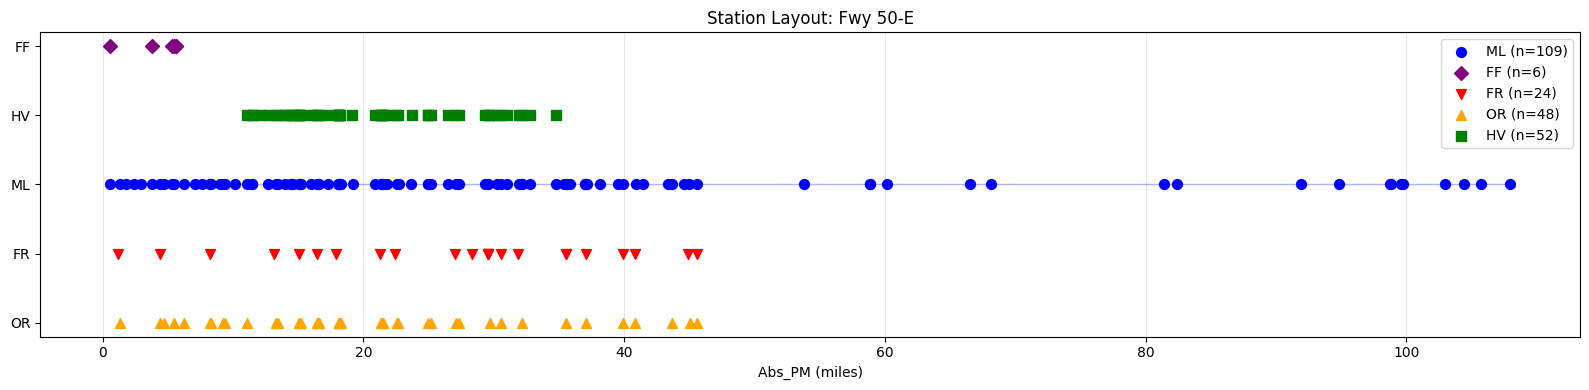

In [18]:
# 可视化：站点沿高速的分布
type_colors = {'ML': 'blue', 'HV': 'green', 'FR': 'red', 'OR': 'orange', 'FF': 'purple'}
type_markers = {'ML': 'o', 'HV': 's', 'FR': 'v', 'OR': '^', 'FF': 'D'}
type_yoffset = {'ML': 0, 'HV': 1, 'FR': -1, 'OR': -2, 'FF': 2}

fig, ax = plt.subplots(figsize=(16, 4))

for t in fwy_stations['Type'].unique():
    subset = fwy_stations[fwy_stations['Type'] == t]
    y = type_yoffset.get(t, 0)
    ax.scatter(
        subset['Abs_PM'], [y] * len(subset),
        c=type_colors.get(t, 'gray'),
        marker=type_markers.get(t, 'o'),
        s=50, label=f"{t} (n={len(subset)})",
        zorder=3
    )

# ML 之间画线
ml_stations = fwy_stations[fwy_stations['Type'] == 'ML'].sort_values('Abs_PM')
ax.plot(ml_stations['Abs_PM'], [0]*len(ml_stations), 'b-', alpha=0.3, linewidth=1)

ax.set_xlabel('Abs_PM (miles)')
ax.set_yticks(list(type_yoffset.values()))
ax.set_yticklabels(list(type_yoffset.keys()))
ax.set_title(f'Station Layout: Fwy {fwy_id}-{fwy_dir}')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f'station_layout_{fwy_id}_{fwy_dir}.png'), dpi=150)
plt.show()

## 8. 同位置多类型重叠的详细分析

In [19]:
# 全面的位置重叠矩阵：哪些类型之间存在重叠
print("="*60)
print("类型间同位置重叠矩阵")
print("="*60)

all_types = sorted(meta_df['Type'].unique())
overlap_matrix = pd.DataFrame(0, index=all_types, columns=all_types)

for _, group in colocated_df.iterrows():
    types = group['Station_Types']
    for i, t1 in enumerate(types):
        for j, t2 in enumerate(types):
            if i < j:
                overlap_matrix.loc[t1, t2] += 1
                overlap_matrix.loc[t2, t1] += 1

print("\n同位置重叠次数:")
display(overlap_matrix)

类型间同位置重叠矩阵

同位置重叠次数:


,FF,FR,HV,ML,OR
FF,6,4,1,19,3
FR,4,50,58,167,116
HV,1,58,56,294,176
ML,19,167,294,218,415
OR,3,116,176,415,136


In [20]:
# 每个站点标记是否属于同位置组
station_to_group = {}
for _, group in colocated_df.iterrows():
    for sid in group['Station_IDs']:
        station_to_group[sid] = group['Group_ID']

meta_df['Colocated_Group'] = meta_df['ID'].map(station_to_group)
meta_df['Is_Colocated'] = meta_df['Colocated_Group'].notna()

print("各类型的同位置占比:")
for t in all_types:
    subset = meta_df[meta_df['Type'] == t]
    n_coloc = subset['Is_Colocated'].sum()
    print(f"  {t}: {n_coloc}/{len(subset)} ({n_coloc/len(subset)*100:.1f}%) 属于同位置组")

各类型的同位置占比:
  FF: 24/28 (85.7%) 属于同位置组
  FR: 165/271 (60.9%) 属于同位置组
  HV: 234/272 (86.0%) 属于同位置组
  ML: 565/871 (64.9%) 属于同位置组
  OR: 381/417 (91.4%) 属于同位置组


## 9. 汇总 & 保存

In [21]:
# 保存同位置组
# 展开为每行一个站点
colocated_expanded = []
for _, group in colocated_df.iterrows():
    for sid, stype, slanes in zip(group['Station_IDs'], 
                                   group['Station_Types'], 
                                   group['Station_Lanes']):
        colocated_expanded.append({
            'Group_ID': group['Group_ID'],
            'Station_ID': sid,
            'Type': stype,
            'Lanes': slanes,
            'Fwy': group['Fwy'],
            'Dir': group['Dir'],
            'Types_In_Group': group['Types'],
            'N_In_Group': group['N_Stations'],
        })

colocated_expanded_df = pd.DataFrame(colocated_expanded)
colocated_expanded_df.to_csv(os.path.join(OUTPUT_DIR, f'colocated_groups_{TARGET_DATE}.csv'), index=False)

# 保存匝道-ML 映射
ramp_ml_df.to_csv(os.path.join(OUTPUT_DIR, f'ramp_ml_mapping_{TARGET_DATE}.csv'), index=False)

# 保存 HV-ML 映射
if len(hv_ml_df) > 0:
    hv_ml_df.to_csv(os.path.join(OUTPUT_DIR, f'hv_ml_mapping_{TARGET_DATE}.csv'), index=False)

# 保存高速公路 profile
profiles_df.to_csv(os.path.join(OUTPUT_DIR, f'freeway_profiles_{TARGET_DATE}.csv'), index=False)

print("所有结果已保存!")
print(f"输出目录: {OUTPUT_DIR}")

所有结果已保存!
输出目录: ../output/topology_analysis


In [22]:
# 汇总报告
print("\n" + "="*60)
print("汇总报告")
print("="*60)

print(f"\n日期: {TARGET_DATE}")
print(f"元数据日期: {meta_date.strftime('%Y-%m-%d')}")
print(f"同位置阈值: {COLOCATION_THRESHOLD} 英里")

print(f"\n--- 站点类型 ---")
for t in all_types:
    print(f"  {t}: {(meta_df['Type'] == t).sum()}")
print(f"  总计: {len(meta_df)}")

print(f"\n--- 同位置组 ---")
print(f"  同位置组数: {len(colocated_df)}")
print(f"  涉及站点数: {len(colocated_expanded_df)}")
print(f"  类型组合分布:")
for combo, count in type_combo_counts.items():
    print(f"    {combo}: {count}")

print(f"\n--- 匝道与 ML ---")
if len(valid_ramps) > 0:
    print(f"  匝道总数: {len(ramp_ml_df)}")
    print(f"  有对应 ML: {len(valid_ramps)}")
    print(f"  与 ML 同位置: {valid_ramps['Is_Colocated'].sum()}")
    print(f"  中位距离: {valid_ramps['Distance_to_ML'].median():.3f} mi")

print(f"\n--- HV 与 ML ---")
if len(hv_ml_df) > 0 and len(hv_ml_df[hv_ml_df['Distance'].notna()]) > 0:
    valid_hv = hv_ml_df[hv_ml_df['Distance'].notna()]
    print(f"  HV 总数: {len(hv_ml_df)}")
    print(f"  与 ML 同位置: {valid_hv['Is_Colocated'].sum()}")
    print(f"  中位距离: {valid_hv['Distance'].median():.3f} mi")


汇总报告

日期: 2025_01_15
元数据日期: 2024-11-27
同位置阈值: 0.05 英里

--- 站点类型 ---
  FF: 28
  FR: 271
  HV: 272
  ML: 871
  OR: 417
  总计: 1859

--- 同位置组 ---
  同位置组数: 493
  涉及站点数: 1369
  类型组合分布:
    ML+OR: 129
    HV+ML+OR: 83
    HV+ML: 80
    FR+ML+OR: 63
    ML: 32
    FR+ML: 31
    FR+HV+ML+OR: 27
    FF+ML: 11
    FR+HV+ML: 10
    FR+OR: 6
    HV+OR: 5
    FF+FR+ML: 3
    FR+HV: 3
    FF: 3
    FF+ML+OR: 2
    FR: 1
    FR+HV+OR: 1
    FF+OR: 1
    OR: 1
    FF+HV: 1

--- 匝道与 ML ---
  匝道总数: 688
  有对应 ML: 686
  与 ML 同位置: 527
  中位距离: 0.007 mi

--- HV 与 ML ---
  HV 总数: 272
  与 ML 同位置: 231
  中位距离: 0.006 mi
